# 분석 및 모델링 준비

user_feat_final.csv를 불러오고, 분석/모델링을 위한 데이터 전처리 및 feature/target 분리 과정을 진행합니다.

In [ ]:
# 1. 주요 라이브러리 import
import pandas as pd
import numpy as np

# 2. 데이터 불러오기
df = pd.read_csv('user_feat_final.csv')

# 3. 데이터 기본 정보 확인
display(df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all'))
display(df.isnull().sum())

# 5. feature/target 분리 (예시: 결제 여부 is_payment를 target으로)
X = df.drop(columns=['is_payment']) if 'is_payment' in df.columns else df.copy()
y = df['is_payment'] if 'is_payment' in df.columns else None

# 식별자 제거
X = X.drop(columns=['user_uuid'], errors='ignore')
# 원핫 인코딩 대상 지정
onehot_cols = ['register_weekday', 'preferred_site_id_enc']
# 원핫 인코딩
X = pd.get_dummies(X, columns=onehot_cols, drop_first=True)

# 결과 확인
print(X.shape)
X.head()

(6025, 21)

,user_uuid,register_weekday,register_is_weekend,first_visit_delay,visit_days,total_stay_time,avg_stay_time,std_stay_time,visit_weekdays,visit_weekend,...,preferred_site_id,afternoon,morning,night,entry_count,exit_count,stay_density,is_big_site_user,is_payment,preferred_site_id_enc
0,acf3e288-4487-492b-9477-df149fb72e83,6,1,0.0,2.0,38342.0,19171.000000,6570.436211,0.500000,1.0,...,6.0,0.5,0.5,0.0,12.0,14.0,127.806667,1.0,0,9
1,a75029c4-57c6-4f98-bb8f-c669e3371eaa,6,1,1.0,1.0,9633.0,9633.000000,0.000000,1.000000,0.0,...,17.0,0.0,1.0,0.0,4.0,4.0,192.660000,0.0,0,2
2,0e58ea5a-ebe4-48cb-b31b-d02a4f350cf8,6,1,0.0,2.0,38522.0,19261.000000,12092.940172,0.500000,1.0,...,3.0,1.0,0.0,0.0,8.0,8.0,128.406667,1.0,1,4
3,a806f6d6-4bea-40df-b870-212859386e9d,5,1,0.0,2.0,8461.0,4230.500000,3507.956741,0.000000,1.0,...,2.0,0.0,0.0,1.0,3.0,3.0,42.305000,1.0,0,3
4,e9b1a5df-d70c-4ccf-af22-64fdae98d3a2,5,1,0.0,3.0,38932.0,12977.333333,1249.509637,0.333333,1.0,...,4.0,1.0,0.0,0.0,12.0,12.0,129.773333,1.0,0,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6025 entries, 0 to 6024
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_uuid              6025 non-null   object 
 1   register_weekday       6025 non-null   int64  
 2   register_is_weekend    6025 non-null   int64  
 3   first_visit_delay      6025 non-null   float64
 4   visit_days             6025 non-null   float64
 5   total_stay_time        6025 non-null   float64
 6   avg_stay_time          6025 non-null   float64
 7   std_stay_time          6025 non-null   float64
 8   visit_weekdays         6025 non-null   float64
 9   visit_weekend          6025 non-null   float64
 10  site_count             6025 non-null   float64
 11  preferred_site_id      6025 non-null   float64
 12  afternoon              6025 non-null   float64
 13  morning                6025 non-null   float64
 14  night                  6025 non-null   float64
 15  entr

None

,user_uuid,register_weekday,register_is_weekend,first_visit_delay,visit_days,total_stay_time,avg_stay_time,std_stay_time,visit_weekdays,visit_weekend,...,preferred_site_id,afternoon,morning,night,entry_count,exit_count,stay_density,is_big_site_user,is_payment,preferred_site_id_enc
count,6025,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,...,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000
unique,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,acf3e288-4487-492b-9477-df149fb72e83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.344564,0.152863,0.890954,1.778755,30359.800664,16090.793021,3682.162279,0.783826,0.302407,...,7.417427,0.476852,0.261928,0.260722,5.334772,5.238672,163.127065,0.720664,0.387718,4.862739
std,NaN,1.898079,0.359885,0.657392,0.795080,25395.547944,10494.127906,6083.235736,0.357958,0.459339,...,11.582325,0.444619,0.394768,0.397416,4.741557,4.685827,123.878607,0.448710,0.487270,2.757685
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1.000000,0.000000,0.000000,1.000000,11181.000000,8371.000000,0.000000,0.500000,0.000000,...,2.000000,0.000000,0.000000,0.000000,2.000000,2.000000,73.386667,0.000000,0.000000,3.000000
50%,NaN,2.000000,0.000000,1.000000,2.000000,23190.000000,14641.333333,759.116153,1.000000,0.000000,...,3.000000,0.500000,0.000000,0.000000,4.000000,4.000000,133.775000,1.000000,0.000000,4.000000
75%,NaN,4.000000,0.000000,1.000000,2.000000,43009.000000,21933.333333,5444.015108,1.000000,1.000000,...,6.000000,1.000000,0.500000,0.500000,7.000000,7.000000,217.360000,1.000000,1.000000,8.000000


user_uuid                0
register_weekday         0
register_is_weekend      0
first_visit_delay        0
visit_days               0
total_stay_time          0
avg_stay_time            0
std_stay_time            0
visit_weekdays           0
visit_weekend            0
site_count               0
preferred_site_id        0
afternoon                0
morning                  0
night                    0
entry_count              0
exit_count               0
stay_density             0
is_big_site_user         0
is_payment               0
preferred_site_id_enc    0
dtype: int64

(6025, 32)


,register_is_weekend,first_visit_delay,visit_days,total_stay_time,avg_stay_time,std_stay_time,visit_weekdays,visit_weekend,site_count,preferred_site_id,...,register_weekday_6,preferred_site_id_enc_1,preferred_site_id_enc_2,preferred_site_id_enc_3,preferred_site_id_enc_4,preferred_site_id_enc_5,preferred_site_id_enc_6,preferred_site_id_enc_7,preferred_site_id_enc_8,preferred_site_id_enc_9
0,1.0,0.0,2.0,38342.0,19171.000000,6570.436211,0.500000,1.0,1.0,6.0,...,True,False,False,False,False,False,False,False,False,True
1,1.0,1.0,1.0,9633.0,9633.000000,0.000000,1.000000,0.0,1.0,17.0,...,True,False,True,False,False,False,False,False,False,False
2,1.0,0.0,2.0,38522.0,19261.000000,12092.940172,0.500000,1.0,1.0,3.0,...,True,False,False,False,True,False,False,False,False,False
3,1.0,0.0,2.0,8461.0,4230.500000,3507.956741,0.000000,1.0,1.0,2.0,...,False,False,False,True,False,False,False,False,False,False
4,1.0,0.0,3.0,38932.0,12977.333333,1249.509637,0.333333,1.0,1.0,4.0,...,False,False,False,False,False,True,False,False,False,False


In [14]:
# 6. train/test 데이터셋 분할
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if y is not None else None
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (4820, 32)
X_test: (1205, 32)
y_train: (4820,)
y_test: (1205,)


## 모델링

In [15]:
# 앙상블 모델 5종 및 주요 분류 스코어 비교
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}

# Voting 앙상블 추가
voting = VotingClassifier(
    estimators=[
        ('rf', models['RandomForest']),
        ('gb', models['GradientBoosting']),
        ('xgb', models['XGBoost']),
        ('lgbm', models['LightGBM']),
        ('ada', models['AdaBoost'])
    ],
    voting='soft'
)
models['Voting'] = voting

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, 'predict_proba') else None
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC': auc
    })

import pandas as pd
score_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
print('앙상블 모델별 성능 비교')
display(score_df)

c:\Users\ypsoo\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:41:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1869, number of negative: 2951
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1172
[LightGBM] [Info] Number of data points in the train set: 4820, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.387759 -> initscore=-0.456741
[LightGBM] [Info] Start training from score -0.456741


c:\Users\ypsoo\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:41:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1869, number of negative: 2951
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1172
[LightGBM] [Info] Number of data points in the train set: 4820, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.387759 -> initscore=-0.456741
[LightGBM] [Info] Start training from score -0.456741
앙상블 모델별 성능 비교


,Model,Accuracy,Precision,Recall,F1,AUC
0,AdaBoost,0.634025,0.552419,0.293362,0.383217,0.651941
1,Voting,0.648963,0.584615,0.325482,0.418157,0.649748
2,GradientBoosting,0.641494,0.575107,0.286938,0.382857,0.647432
3,RandomForest,0.640664,0.550000,0.400428,0.463445,0.646109
4,LightGBM,0.636515,0.550523,0.338330,0.419098,0.626348
5,XGBoost,0.616598,0.507375,0.368308,0.426799,0.608841


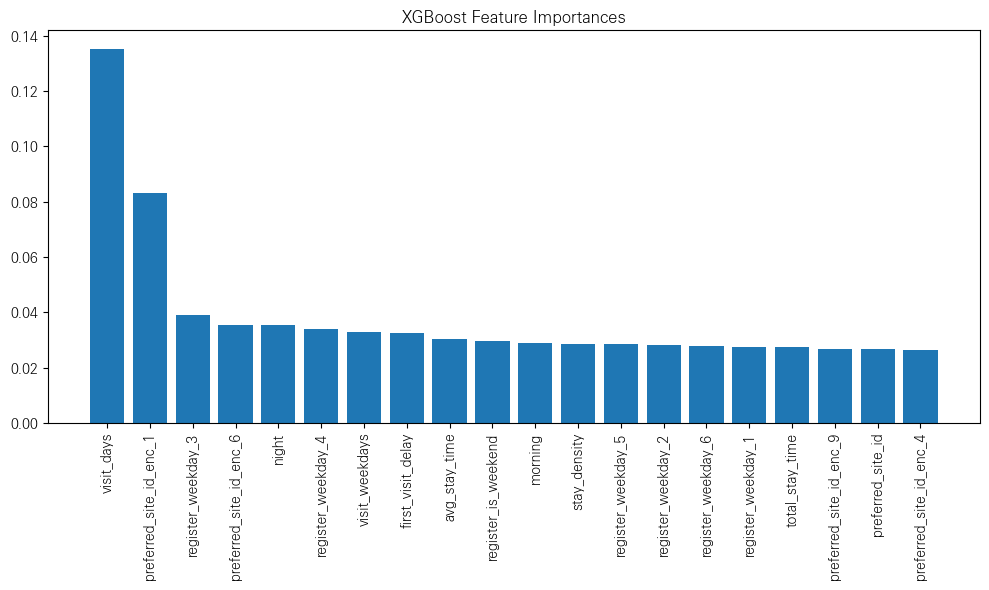

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# XGBoost 모델 객체
xgb_model = models['XGBoost']

# 피처 이름
feature_names = X_train.columns

# 피처 중요도 추출
importances = xgb_model.feature_importances_

# 중요도 순으로 정렬
indices = np.argsort(importances)[::-1]

# 상위 20개 피처만 보기 (원하면 개수 조절)
top_n = 20
plt.figure(figsize=(10, 6))
plt.title("XGBoost Feature Importances")
plt.bar(range(top_n), importances[indices][:top_n], align="center")
plt.xticks(range(top_n), feature_names[indices][:top_n], rotation=90)
plt.tight_layout()
plt.show()